# Analytical Mantle Flow: Educational Workflow

This notebook is a guided walkthrough of the modeling logic in this repository. It begins with two simple idealized geometries so you can build intuition, then scales up to a global plate-boundary case from Holt and Royden (2020).


## 0) Setup and Run Mode

- `RUN_HEAVY = False`: use the precomputed outputs already shipped in the repo (fast, no long reruns).
- `RUN_HEAVY = True`: rerun the scripts from inputs to regenerate outputs (slower, useful for full reproducibility).

Tip: start with `False`, then switch to `True` once you understand the workflow.

Heavy runs in this notebook use `Subgrd_Fast.inp` (10 deg global output interval) to reduce runtime.

If a required precomputed file is missing, the helpers below will print a clear message showing what to generate.


In [1]:
from pathlib import Path
import os
import subprocess
import sys
import numpy as np
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
ROOT = CWD if (CWD / 'flow_computations').exists() else CWD.parent
if not (ROOT / 'flow_computations').exists():
    for parent in CWD.parents:
        if (parent / 'flow_computations').exists():
            ROOT = parent
            break
if not (ROOT / 'flow_computations').exists():
    raise RuntimeError('Could not locate repository root containing flow_computations/.')

FLOW = ROOT / 'flow_computations'
RUN_HEAVY = True

print('Repo root:', ROOT)
print('RUN_HEAVY =', RUN_HEAVY)


Repo root: /home/holt/Projects/Analytical-mantle-flow-modeling
RUN_HEAVY = True


In [2]:
def run(cmd, cwd=FLOW, env=None, timeout_s=None):
    run_env = os.environ.copy() if env is None else dict(env)
    run_env.setdefault('MPLCONFIGDIR', '/tmp/mplcfg')
    run_env.setdefault('XDG_CACHE_HOME', '/tmp')
    print('$', ' '.join(cmd))
    if timeout_s is not None:
        print(f'  timeout: {timeout_s}s')
    t0 = __import__('time').perf_counter()
    subprocess.run(cmd, cwd=str(cwd), check=True, env=run_env, timeout=timeout_s)
    dt = __import__('time').perf_counter() - t0
    print(f'  -> command runtime: {dt:.2f}s')

def require_file(path, hint=None):
    path = Path(path)
    if path.exists():
        return True
    print(f'Missing required file: {path}')
    if hint:
        print(f'  hint: {hint}')
    return False

def show_image(path, title=None):
    path = Path(path)
    if not path.exists():
        print('Missing image:', path)
        return
    img = plt.imread(path)
    plt.figure(figsize=(12, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(title or path.name)
    plt.show()

def summarize_dp(path, label=None):
    path = Path(path)
    if not path.exists():
        print('Missing DP file:', path)
        return None
    arr = np.loadtxt(path)
    vec = arr[:, 4]
    stats = {
        'label': label or path.parent.name,
        'rows': int(vec.shape[0]),
        'mean': float(np.mean(vec)),
        'median': float(np.median(vec)),
        'min': float(np.min(vec)),
        'max': float(np.max(vec)),
    }
    print(
        f"{stats['label']}: rows={stats['rows']}, mean={stats['mean']:.3f}, "
        f"median={stats['median']:.3f}, min={stats['min']:.3f}, max={stats['max']:.3f}"
    )
    return stats


## 1) Idealized Sequence: Small -> Large -> Faster -> Advancing -> Slab Gap

We start with five idealized examples in this exact order:
1. `SmallSP_RetreatingTrench`
2. `LargeSP_RetreatingTrench`
3. `LargeSP_RetreatingTrench_FastPlate` (derived input: plate Euler rate `0.45 -> 0.65 deg/Myr`)
4. `LargeSP_AdvancingTrench` (derived input: slab-wall trench velocity sign flip `vt_ew: +50 -> -50 mm/yr`)
5. `LargeSP_RetreatingTrenchSlabGap`

Shared pressure-run settings (kept fixed across these five cases):
- `amu=3.0e20` Pa s
- `flux_slab=0` (no slab flux)
- `flux_width=500000` m
- `flux_alpha=0`
- `no_flux_for_slabtails=0`
- `grid=Subgrd_Fast.inp`
- `amu_plot=4.0e20` Pa s

Execution controls in the code cell below:
- `CASE_SELECTION`: run only selected case labels (or `None` for all)
- `FORCE_RERUN`: if `False`, heavy mode skips cases with existing DP+plot outputs
- `HEAVY_TIMEOUT_S`: optional per-case timeout in seconds (`None` disables timeout)


Idealized sequence run settings:
  amu=3.0e20, flux_slab=0, flux_width=500000, flux_alpha=0, no_flux_for_slabtails=0, grid=Subgrd_Fast.inp, amu_plot=4.0e20

Case 1: Small retreating trench
  change: baseline small plate retreating trench
$ /home/holt/miniconda3/envs/mantle-flow-modeling/bin/python3 global_pressure_withPressurePlot.py SmallSP_RetreatingTrench 3.0e20 0 500000 0 0 Subgrd_Fast.inp 4.0e20
reading input and segmenting boundaries...
------------------------
8 original boundaries
input done.
---
timing: input + segmentation = 0.00s
---
setting up pressure inversion points...
pressure points set up.
---
timing: pressure point setup = 0.03s
---
building matrix...
matrix built.
---
timing: matrix build = 3.37s
---
building rhs vector...
rhs vector built.
---
timing: rhs build = 0.00s
---
timing: total setup (pre-inversion) = 3.40s.
---
inverting matrix...
matrix inversion takes 0.01s.
---
outputting solution on a grid...
timing: grid output = 6.03s (spacing=10.00 deg)
---
outputt

Traceback (most recent call last):
  File "/home/holt/Projects/Analytical-mantle-flow-modeling/flow_computations/global_pressure_withPressurePlot.py", line 142, in <module>
    plot_pressure_components(lons_out,lats_out,P_out,Pwall_out,Pedge_out,lona,lata,lonb,latb,lono,lato,iwall,DP,vt_ew,vt_ns,polygon_points,\
  File "/home/holt/Projects/Analytical-mantle-flow-modeling/flow_computations/plotting.py", line 76, in plot_pressure_components
    cs = map.contourf(x,y,P_out,levels=np.linspace(-60,60,121),cmap=cm.get_cmap('bwr'),extend="both")
  File "/home/holt/.local/lib/python3.10/site-packages/mpl_toolkits/basemap/__init__.py", line 549, in with_transform
    return plotfunc(self,x,y,data,*args,**kwargs)
  File "/home/holt/.local/lib/python3.10/site-packages/mpl_toolkits/basemap/__init__.py", line 3704, in contourf
    CS.collections,c = self._cliplimb(ax,CS.collections)
AttributeError: 'QuadContourSet' object has no attribute 'collections'


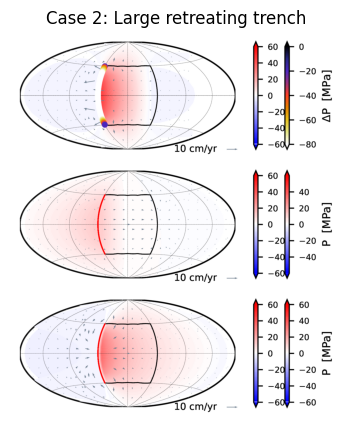


Case 3: Large retreating trench (faster plate)
  change: Subfil Euler rate changed from 0.45 to 0.65 deg/Myr
$ /home/holt/miniconda3/envs/mantle-flow-modeling/bin/python3 global_pressure_withPressurePlot.py LargeSP_RetreatingTrench_FastPlate 3.0e20 0 500000 0 0 Subgrd_Fast.inp 4.0e20
reading input and segmenting boundaries...
------------------------
13 original boundaries
input done.
---
timing: input + segmentation = 0.01s
---
setting up pressure inversion points...
pressure points set up.
---
timing: pressure point setup = 0.05s
---
building matrix...
matrix built.
---
timing: matrix build = 11.55s
---
building rhs vector...
rhs vector built.
---
timing: rhs build = 0.00s
---
timing: total setup (pre-inversion) = 11.61s.
---
inverting matrix...
matrix inversion takes 0.02s.
---
outputting solution on a grid...
timing: grid output = 10.90s (spacing=10.00 deg)
---
outputting across-slab DP...
timing: DP output = 5.05s
---
saving Pcoeff and DP in text_files/LargeSP_RetreatingTrench_Fa

Traceback (most recent call last):
  File "/home/holt/Projects/Analytical-mantle-flow-modeling/flow_computations/global_pressure_withPressurePlot.py", line 142, in <module>
    plot_pressure_components(lons_out,lats_out,P_out,Pwall_out,Pedge_out,lona,lata,lonb,latb,lono,lato,iwall,DP,vt_ew,vt_ns,polygon_points,\
  File "/home/holt/Projects/Analytical-mantle-flow-modeling/flow_computations/plotting.py", line 76, in plot_pressure_components
    cs = map.contourf(x,y,P_out,levels=np.linspace(-60,60,121),cmap=cm.get_cmap('bwr'),extend="both")
  File "/home/holt/.local/lib/python3.10/site-packages/mpl_toolkits/basemap/__init__.py", line 549, in with_transform
    return plotfunc(self,x,y,data,*args,**kwargs)
  File "/home/holt/.local/lib/python3.10/site-packages/mpl_toolkits/basemap/__init__.py", line 3704, in contourf
    CS.collections,c = self._cliplimb(ax,CS.collections)
AttributeError: 'QuadContourSet' object has no attribute 'collections'
Traceback (most recent call last):
  File "/ho

reading input and segmenting boundaries...
------------------------
13 original boundaries
input done.
---
timing: input + segmentation = 0.01s
---
setting up pressure inversion points...
pressure points set up.
---
timing: pressure point setup = 0.06s
---
building matrix...
matrix built.
---
timing: matrix build = 13.01s
---
building rhs vector...
rhs vector built.
---
timing: rhs build = 0.00s
---
timing: total setup (pre-inversion) = 13.08s.
---
inverting matrix...
matrix inversion takes 0.03s.
---
outputting solution on a grid...
timing: grid output = 12.42s (spacing=10.00 deg)
---
outputting across-slab DP...
timing: DP output = 5.76s
---
saving Pcoeff and DP in text_files/LargeSP_AdvancingTrench.3e+20noslabflux/
timing: save outputs = 0.00s
---
plotting...
may not be what you expect.  If it looks odd, your can either
adjust the map projection region to be consistent with your data, or
(if your data is on a global lat/lon grid) use the shiftgrid
function to adjust the data to be c

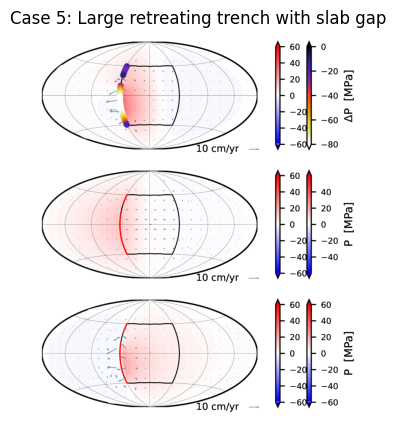

In [3]:
import shutil

AMU = '3.0e20'
FLUX_SLAB = '0'
FLUX_WIDTH = '500000'
FLUX_ALPHA = '0'
NO_FLUX_FOR_SLABTAILS = '0'
GRID_NAME = 'Subgrd_Fast.inp'
AMU_PLOT = '4.0e20'
AMU_TAG = str(float(AMU))
AMU_PLOT_TAG = str(float(AMU_PLOT))

FORCE_RERUN = False
CASE_SELECTION = None  # e.g. ['Case 3: Large retreating trench (faster plate)']
HEAVY_TIMEOUT_S = None

def write_fast_plate_variant():
    # Fast-plate variant needs BOTH boundary and domain files for model-name lookup.
    src_bon = FLOW / 'inputs' / 'Subbon_LargeSP_RetreatingTrench.inp'
    dst_bon = FLOW / 'inputs' / 'Subbon_LargeSP_RetreatingTrench_FastPlate.inp'
    shutil.copyfile(src_bon, dst_bon)

    src_fil = FLOW / 'inputs' / 'Subfil_LargeSP_RetreatingTrench.inp'
    dst_fil = FLOW / 'inputs' / 'Subfil_LargeSP_RetreatingTrench_FastPlate.inp'
    lines = src_fil.read_text().splitlines()
    cols = lines[1].split('	')
    cols[3] = '0.65'  # faster plate motion (deg/Myr)
    lines[1] = '	'.join(cols)
    dst_fil.write_text('\n'.join(lines) + '\n')

def write_advancing_trench_variant():
    src_bon = FLOW / 'inputs' / 'Subbon_LargeSP_RetreatingTrench.inp'
    dst_bon = FLOW / 'inputs' / 'Subbon_LargeSP_AdvancingTrench.inp'
    out = []
    for line in src_bon.read_text().splitlines():
        cols = line.split('	')
        if cols[0] == '1':
            cols[7] = f"{-float(cols[7]):.1f}"  # flip vt_ew sign
            cols[8] = f"{-float(cols[8]):.1f}"  # flip vt_ns sign
        out.append('\t'.join(cols))
    dst_bon.write_text('\n'.join(out) + '\n')

    src_fil = FLOW / 'inputs' / 'Subfil_LargeSP_RetreatingTrench.inp'
    dst_fil = FLOW / 'inputs' / 'Subfil_LargeSP_AdvancingTrench.inp'
    shutil.copyfile(src_fil, dst_fil)

if RUN_HEAVY:
    write_fast_plate_variant()
    write_advancing_trench_variant()

idealized_cases = [
    {
        'label': 'Case 1: Small retreating trench',
        'model': 'SmallSP_RetreatingTrench',
        'change': 'baseline small plate retreating trench',
    },
    {
        'label': 'Case 2: Large retreating trench',
        'model': 'LargeSP_RetreatingTrench',
        'change': 'plate size changed (small -> large), trench style unchanged',
    },
    {
        'label': 'Case 3: Large retreating trench (faster plate)',
        'model': 'LargeSP_RetreatingTrench_FastPlate',
        'change': 'Subfil Euler rate changed from 0.45 to 0.65 deg/Myr',
    },
    {
        'label': 'Case 4: Large advancing trench',
        'model': 'LargeSP_AdvancingTrench',
        'change': 'Subbon slab-wall trench velocity flipped: vt_ew +50 -> -50 mm/yr',
    },
    {
        'label': 'Case 5: Large retreating trench with slab gap',
        'model': 'LargeSP_RetreatingTrenchSlabGap',
        'change': 'slab-gap geometry introduced',
    },
]

idealized_stats = []

print('Idealized sequence run settings:')
print(f'  amu={AMU}, flux_slab={FLUX_SLAB}, flux_width={FLUX_WIDTH}, flux_alpha={FLUX_ALPHA}, no_flux_for_slabtails={NO_FLUX_FOR_SLABTAILS}, grid={GRID_NAME}, amu_plot={AMU_PLOT}')

for case in idealized_cases:
    print(f"\n{case['label']}")
    print(f"  change: {case['change']}")

    out_dir = FLOW / 'text_files' / f"{case['model']}.{AMU_TAG}noslabflux"
    plot_path = FLOW / 'plots' / 'pressure_fields' / f"{case['model']}.{AMU_TAG}noslabflux.plotvisc{AMU_PLOT_TAG}.png"

    if CASE_SELECTION is not None and case['label'] not in CASE_SELECTION:
        print('  skipped by CASE_SELECTION')
        continue

    has_outputs = (out_dir / 'DP.txt').exists() and plot_path.exists()

    if RUN_HEAVY:
        if has_outputs and not FORCE_RERUN:
            print('  using existing outputs (set FORCE_RERUN=True to recompute)')
        else:
            try:
                run([
                    sys.executable,
                    'global_pressure_withPressurePlot.py',
                    case['model'],
                    AMU,
                    FLUX_SLAB,
                    FLUX_WIDTH,
                    FLUX_ALPHA,
                    NO_FLUX_FOR_SLABTAILS,
                    GRID_NAME,
                    AMU_PLOT,
                ], timeout_s=HEAVY_TIMEOUT_S)
            except subprocess.CalledProcessError as exc:
                dp_file = out_dir / 'DP.txt'
                if dp_file.exists():
                    print('  pressure run returned non-zero after DP save (often plotting backend); continuing with saved DP.')
                else:
                    raise

    stats = summarize_dp(out_dir / 'DP.txt', label=case['label'])
    if stats is not None:
        stats['change'] = case['change']
        idealized_stats.append(stats)

    show_image(plot_path, title=case['label'])


## 2) Compare the Five Idealized Cases

This table is intended to make geometry/kinematic changes explicit and easy to compare.


In [4]:
if idealized_stats:
    print('DP summary comparison (five idealized cases):')
    print(f"{'case':<46} {'rows':>6} {'mean':>10} {'median':>10} {'min':>10} {'max':>10}")
    for s in idealized_stats:
        print(f"{s['label']:<46} {s['rows']:>6d} {s['mean']:>10.3f} {s['median']:>10.3f} {s['min']:>10.3f} {s['max']:>10.3f}")

    print('\nWhat changed by case:')
    for s in idealized_stats:
        print(f"- {s['label']}: {s['change']}")

    base = idealized_stats[0]
    print(f"\nDeltas relative to first available case ({base['label']}):")
    for s in idealized_stats[1:]:
        print(
            f"- {s['label']}: mean={s['mean'] - base['mean']:+.3f}, "
            f"median={s['median'] - base['median']:+.3f}, "
            f"range={(s['max'] - s['min']) - (base['max'] - base['min']):+.3f}"
        )
else:
    print('No idealized DP outputs found yet. Set RUN_HEAVY=True to generate missing cases.')


DP summary comparison (five idealized cases):
case                                             rows       mean     median        min        max
Case 1: Small retreating trench                   178     21.490     23.442     -0.008     46.748
Case 2: Large retreating trench                   328     46.649     55.832     -0.008     96.326
Case 3: Large retreating trench (faster plate)    328     51.938     61.881     -0.013    107.548
Case 4: Large advancing trench                    328    -22.850    -28.611    -45.827      0.000
Case 5: Large retreating trench with slab gap     303     24.260     15.306     -0.009     64.269

What changed by case:
- Case 1: Small retreating trench: baseline small plate retreating trench
- Case 2: Large retreating trench: plate size changed (small -> large), trench style unchanged
- Case 3: Large retreating trench (faster plate): Subfil Euler rate changed from 0.45 to 0.65 deg/Myr
- Case 4: Large advancing trench: Subbon slab-wall trench velocity flipp

## 3) Global Case: From Pressure to Dip Comparison

Now we run the full global workflow (or load precomputed outputs):
1. compute global pressure and across-slab `DP`
2. compute subducting plate ages
3. compare modeled dips vs observed dip catalogue

This is the key end-to-end scientific path connecting model physics to observation-based evaluation.


In [ ]:
global_model = 'Slab2.0Final_NoJapTail_nnr_FS'
global_text = FLOW / 'text_files' / f'{global_model}.3e+20_VcSlabFlux_width500000.0_alpha0.0.NoTailFlux'
global_plot = FLOW / 'plots' / 'pressure_fields' / f'{global_model}.3e+20_VcSlabFlux_width500000.0_alpha0.0.NoTailFlux.plotvisc4e+20.png'
global_dip_plot = FLOW / 'plots' / 'dip_comparisons' / f'{global_model}.3e+20_VcSlabFlux_width500000.0_alpha0.0.NoTailFlux.fact1.327.png'

env = os.environ.copy()
env.setdefault('DIPS_OBS_TXT', str(ROOT / 'dip_observations' / 'dip_catalogues' / 'Slab2_const-depth' / 'AllDips.txt'))

if RUN_HEAVY:
    run([sys.executable, 'global_pressure_withPressurePlot.py', global_model, '3.0e20', '2', '500000', '0', '1', 'Subgrd_Fast.inp', '4.0e20'], env=env)
    run([sys.executable, 'get_SPages.py', global_model], env=env)
    run([sys.executable, 'plot_DipComparison_varyDPfactor.py', global_model, '3.0e20', '2', '500000', '0', '1', 'Subgrd_Fast.inp', '2', '12', '4', '5'], env=env)

stats_global = summarize_dp(global_text / 'DP.txt', label='Global')
show_image(global_plot, title='Global Pressure Field')
show_image(global_dip_plot, title='Global Modeled vs Observed Dip Comparison')


$ /home/holt/miniconda3/envs/mantle-flow-modeling/bin/python3 global_pressure_withPressurePlot.py Slab2.0Final_NoJapTail_nnr_FS 3.0e20 2 500000 0 1 Subgrd_Fast.inp 4.0e20


In [ ]:
stats_all = list(idealized_stats)
if stats_global is not None:
    stats_all.append(stats_global)

if len(stats_all) >= 2:
    print('\nDP summary comparison (idealized + global if available):')
    print(f"{'case':<46} {'rows':>6} {'mean':>10} {'median':>10} {'min':>10} {'max':>10}")
    for s in stats_all:
        print(f"{s['label']:<46} {s['rows']:>6d} {s['mean']:>10.3f} {s['median']:>10.3f} {s['min']:>10.3f} {s['max']:>10.3f}")
else:
    print('Not enough DP summaries available for comparison.')


## 4) Interpretation Prompts

Use these questions to guide interpretation:
- How do `DP` magnitude/range shift across the five idealized cases?
- Does faster plate motion (`0.45 -> 0.65 deg/Myr`) change `DP` the way you expected?
- How does trench reversal (`vt_ew +50 -> -50 mm/yr`) alter the pressure pattern?
- How does the slab-gap geometry compare with non-gap large-plate cases?
- Which regions drive the largest modeled-vs-observed dip mismatches in the global run?
